In [15]:
# ── Cell 1: Mount Drive & Unzip ───────────────────────────────
# Only needs to run once per session. Comment out after first run.
# from google.colab import drive
# drive.mount('/content/drive')

# !unzip /content/drive/MyDrive/AppML/jpegs_all_over_6755.zip -d /content/Data_Full
# !unzip /content/drive/MyDrive/AppML/jpegs_all_under_equal_6755.zip -d /content/Data_Full
print('Done unzipping')

import os
print(f'Files in Data_Full: {len(os.listdir("/content/Data_Full"))}')

Done unzipping
Files in Data_Full: 316320


In [16]:
# # Free the old session's memory
# import torch, gc
# del model
# gc.collect()
# torch.cuda.empty_cache()
# print(torch.cuda.memory_summary(abbreviated=True))

In [17]:
import os
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


PyTorch 2.11.0+cu128
Using device: cuda


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURE THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_DIR    = '/content/Data_Full'   # ← change this
IMG_SIZE    = 200
BATCH_SIZE  = 256
NUM_SAMPLES = -1
EPOCHS      = 20
LR          = 1e-3
VAL_SPLIT   = 0.2
DROPOUT     = 0.3
PATIENCE    = 10       # early stopping patience
OUTPUT_DIR  = "output"
SEED        = 42
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [19]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!nvidia-smi
print(torch.cuda.memory_allocated() / 1024**3, "GB")  # should be ~0 after fresh kernel

Wed Jun  3 10:12:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             60W /  400W |    7102MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [20]:
# ── Dataset ───────────────────────────────────────────────────
class PopulationDataset(Dataset):
    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    def __init__(self, root_dir, transform=None, num_samples=-1):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    numbers = re.findall(r"\d+", f.stem)
                    if not numbers:
                        raise ValueError
                    self.samples.append((f, int(numbers[-1])))
                except ValueError:
                    print(f"⚠ Skipping {f.name} — no target in name")

        if num_samples > 0:
            random.shuffle(self.samples)
            self.samples = self.samples[:num_samples]

        targets = [t for _, t in self.samples]
        print(f"✓ Loaded {len(self.samples)} images")
        print(f"  Target range : {min(targets)} – {max(targets)}")
        print(f"  Mean / std   : {np.mean(targets):.1f} / {np.std(targets):.1f}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("L")           # greyscale → 1 channel
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

In [21]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [22]:
# # ── Split & loaders ───────────────────────────────────────────
# full_dataset = PopulationDataset(DATA_DIR, transform=None, num_samples=NUM_SAMPLES)

# # Optional: balance zero vs non-zero samples
# zero_samples    = [s for s in full_dataset.samples if s[1] == 0]
# nonzero_samples = [s for s in full_dataset.samples if s[1] > 0]
# n_balanced = min(len(zero_samples), len(nonzero_samples))
# random.shuffle(zero_samples);  random.shuffle(nonzero_samples)
# full_dataset.samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
# random.shuffle(full_dataset.samples)
# print(f"Balanced: {n_balanced} × 0  +  {n_balanced} × >0  =  {len(full_dataset.samples)} total")

# val_size   = int(len(full_dataset) * VAL_SPLIT)
# train_size = len(full_dataset) - val_size

# train_subset, val_subset = random_split(
#     full_dataset, [train_size, val_size],
#     generator=torch.Generator().manual_seed(SEED),
# )

# # Build separate dataset objects so each gets its own transform
# train_dataset = PopulationDataset.__new__(PopulationDataset)
# train_dataset.root_dir = full_dataset.root_dir
# train_dataset.transform = train_transform
# train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]

# val_dataset = PopulationDataset.__new__(PopulationDataset)
# val_dataset.root_dir = full_dataset.root_dir
# val_dataset.transform = val_transform
# val_dataset.samples = [full_dataset.samples[i] for i in val_subset.indices]

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
#                           num_workers=4,   # was 2, increase this
#                           pin_memory=True,
#                           prefetch_factor=2,
#                           persistent_workers=True)  # keeps workers alive between epochs

# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
#                         num_workers=4,
#                         pin_memory=True,
#                         prefetch_factor=2,
#                         persistent_workers=True)

# print(f"Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")

In [23]:
# # ── Split & loaders ───────────────────────────────────────────
# full_dataset = PopulationDataset(DATA_DIR, transform=None, num_samples=NUM_SAMPLES)

# # Balance zero vs non-zero samples
# zero_samples    = [s for s in full_dataset.samples if s[1] == 0]
# nonzero_samples = [s for s in full_dataset.samples if s[1] > 0]
# n_balanced = min(len(zero_samples), len(nonzero_samples))
# random.shuffle(zero_samples); random.shuffle(nonzero_samples)
# all_samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
# random.shuffle(all_samples)
# print(f"Balanced: {n_balanced} × 0  +  {n_balanced} × >0  =  {len(all_samples)} total")

# val_size      = int(len(all_samples) * VAL_SPLIT)
# train_samples = all_samples[val_size:]
# val_samples   = all_samples[:val_size]

# class CachedDataset(Dataset):
#     def __init__(self, samples, transform=None, img_size=IMG_SIZE):
#         self.transform = transform
#         self.cache = []
#         for path, target in tqdm(samples, desc="Caching"):
#             img = Image.open(path).convert("L").resize((img_size, img_size), Image.BILINEAR)
#             self.cache.append((img.copy(), target))

#     def __len__(self):
#         return len(self.cache)

#     def __getitem__(self, idx):
#         img, target = self.cache[idx]
#         if self.transform:
#             img = self.transform(img)
#         label = 0.0 if target == 0 else 1.0   # binary
#         return img, torch.tensor(label, dtype=torch.float32)

# train_dataset = CachedDataset(train_samples, transform=train_transform, img_size=IMG_SIZE)
# val_dataset   = CachedDataset(val_samples,   transform=val_transform, img_size=IMG_SIZE)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
#                           num_workers=0, pin_memory=True)
# val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
#                           num_workers=0, pin_memory=True)

# print(f"Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")

In [24]:
# ── Split & loaders ───────────────────────────────────────────
full_dataset = PopulationDataset(DATA_DIR, transform=None, num_samples=NUM_SAMPLES)

all_samples = full_dataset.samples.copy()
random.shuffle(all_samples)

zeros    = sum(1 for _, t in all_samples if t == 0)
nonzeros = sum(1 for _, t in all_samples if t > 0)
print(f"Class 0 (not populated): {zeros}")
print(f"Class 1 (populated)    : {nonzeros}")

val_size      = int(len(all_samples) * VAL_SPLIT)
train_samples = all_samples[val_size:]
val_samples   = all_samples[:val_size]

class CachedDataset(Dataset):
    def __init__(self, samples, transform=None, img_size=IMG_SIZE):
        self.transform = transform
        self.cache = []
        for path, target in tqdm(samples, desc="Caching"):
            img = Image.open(path).convert("L").resize((img_size, img_size), Image.BILINEAR)
            self.cache.append((img.copy(), target))

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        img, target = self.cache[idx]
        if self.transform:
            img = self.transform(img)
        label = 0.0 if target == 0 else 1.0
        return img, torch.tensor(label, dtype=torch.float32)

train_dataset = CachedDataset(train_samples, transform=train_transform, img_size=IMG_SIZE)
val_dataset   = CachedDataset(val_samples,   transform=val_transform, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")

✓ Loaded 88869 images
  Target range : 0 – 201
  Mean / std   : 1.3 / 6.8
Class 0 (not populated): 78908
Class 1 (populated)    : 9961


Caching:   0%|          | 0/71096 [00:00<?, ?it/s]

Caching:   0%|          | 0/17773 [00:00<?, ?it/s]

Train: 71096  |  Val: 17773


In [25]:
class CountCNN(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            )

        self.features = nn.Sequential(
            conv_block(1,   32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
            conv_block(256, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(    # renamed from regressor
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),              # raw logit, no ReLU
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x))).squeeze(1)


model = CountCNN().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 4,483,873


In [26]:
# ── Training helpers ──────────────────────────────────────────
# n_zeros    = sum(1 for _, t in train_samples if t == 0)
# n_nonzeros = sum(1 for _, t in train_samples if t > 0)
# pos_weight = torch.tensor([n_zeros / n_nonzeros]).to(device)
criterion  = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                  factor=0.5, patience=5)
scaler = torch.amp.GradScaler("cuda")

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, all_preds, all_targets = 0.0, [], []
    for imgs, targets in tqdm(loader, desc="  train", leave=False):
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
            loss   = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.detach().cpu().float().numpy())
        all_targets.extend(targets.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_targets)).mean()
    return running_loss / len(loader.dataset), acc

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_targets = 0.0, [], []
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
        running_loss += criterion(logits, targets).item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
    all_preds, all_targets = np.array(all_preds), np.array(all_targets)
    acc = (all_preds == all_targets).mean()
    return running_loss / len(loader.dataset), acc, all_preds, all_targets

In [27]:
# ── Training loop ─────────────────────────────────────────────
best_val_loss    = float("inf")
patience_counter = 0
history          = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

pbar = tqdm(range(1, EPOCHS + 1), desc="Epochs")
for epoch in pbar:
    train_loss, train_acc       = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _     = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    pbar.set_postfix(t_loss=f"{train_loss:.4f}", v_loss=f"{val_loss:.4f}",
                     t_acc=f"{train_acc:.3f}", v_acc=f"{val_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": float(val_loss), "val_acc": float(val_acc)},
                   os.path.join(OUTPUT_DIR, "best_model.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch}")
            break

print(f"\n✓ Done — best val loss: {best_val_loss:.4f}")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]

...

  train:   0%|          | 0/278 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]

  train:   0%|          | 0/278 [00:00<?, ?it/s]


✓ Done — best val loss: 0.0742


In [28]:
# ── Final evaluation ──────────────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

ckpt = torch.load(os.path.join(OUTPUT_DIR, "best_model.pth"),
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

val_loss, val_acc, preds, targets = evaluate(model, val_loader, criterion)

print(f"Best model (epoch {ckpt['epoch']})")
print(f"  Val Loss : {val_loss:.4f}")
print(f"  Val Acc  : {val_acc*100:.2f}%")
print()
print(classification_report(targets, preds, target_names=["Not Populated", "Populated"]))

Best model (epoch 17)
  Val Loss : 0.0742
  Val Acc  : 96.83%

               precision    recall  f1-score   support

Not Populated       0.98      0.98      0.98     15767
    Populated       0.85      0.88      0.86      2006

     accuracy                           0.97     17773
    macro avg       0.92      0.93      0.92     17773
 weighted avg       0.97      0.97      0.97     17773



In [29]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "val_loss": float(best_val_loss),
}, os.path.join(OUTPUT_DIR, "final_model_full.pth"))

# Save just the weights (smaller, for inference only)
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "final_weights.pth"))

print(f"✓ Saved to {OUTPUT_DIR}/")

✓ Saved to output/


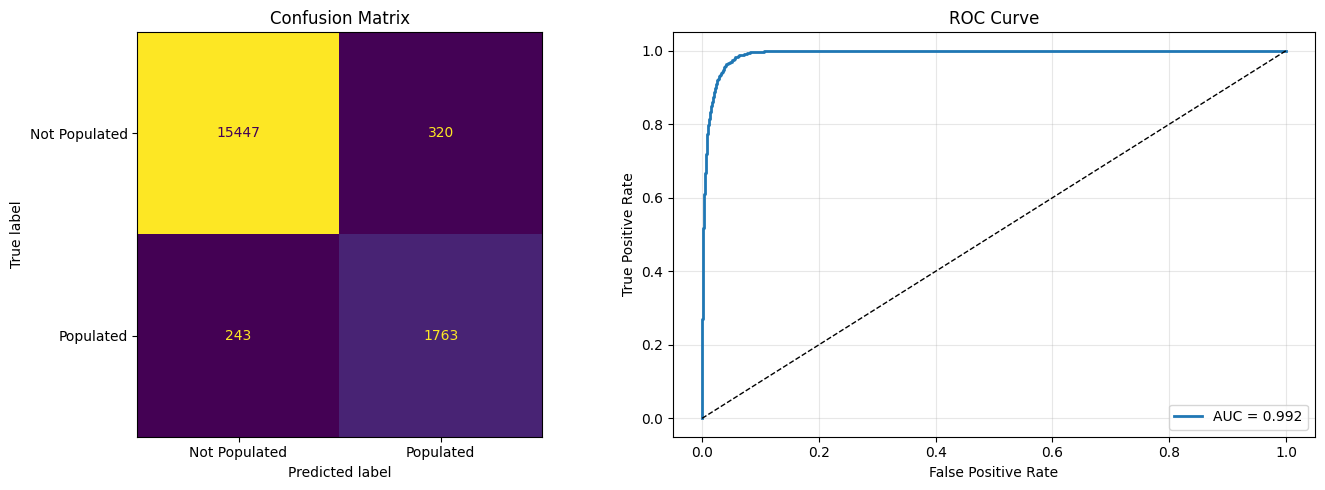

In [30]:
# ── Confusion matrix + ROC ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Populated", "Populated"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

model.eval()
all_probs = []
with torch.no_grad():
    for imgs, _ in val_loader:
        logits = model(imgs.to(device))
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())

all_probs = np.array(all_probs)
auc = roc_auc_score(targets, all_probs)
fpr, tpr, _ = roc_curve(targets, all_probs)

axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "evaluation.png"), dpi=150)
plt.show()

In [31]:
import shutil
shutil.copy(os.path.join(OUTPUT_DIR, "best_model.pth"),
            "/content/drive/MyDrive/AppML/best_model_full.pth")
print("✓ Saved to Drive")

✓ Saved to Drive
